
# Multi-Class Segmentation: U-Net on Synthetic Shapes 

In this notebook, we demonstrate **multi-class segmentation** with multiple objects per image using a tiny **U-Net**.
As input, we use 64×64 grayscale images with 2–4 random shapes (circles, squares, and triangles). Our classes are `0 = background`, `1 = circle`, `2 = square`, `3 = triangle`.  
U-Net outputs 4-channel logits (multi-class) optimized with `CrossEntropyLoss`.

In [1]:
# Import necessary libraries
import math, random
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


First, let's define our synthetic dataset:

In [2]:
# Define synthetic dataset for multi-object segmentation
class ShapesMultiDataset(Dataset):
    def __init__(self, n_samples=1200, size=64, noise_std=0.05, seed=0,
                 min_shapes=2, max_shapes=4, max_tries=100):
        self.n = n_samples
        self.S = size
        self.noise_std = noise_std
        self.seed = seed
        self.min_shapes = min_shapes
        self.max_shapes = max_shapes
        self.max_tries = max_tries

    def __len__(self):
        return self.n

    def _empty_mask(self):
        return Image.fromarray(np.zeros((self.S, self.S), dtype=np.uint8), mode="L")

    def _rand_pos(self, rng, margin:int=8) -> Tuple[int,int]:
        return (rng.randint(margin, self.S - margin),
                rng.randint(margin, self.S - margin))

    def _draw_shape(self, cls, cx, cy, r):
        tmp = self._empty_mask()
        d = ImageDraw.Draw(tmp)
        if cls == 1:
            bbox = (cx - r, cy - r, cx + r, cy + r)
            d.ellipse(bbox, fill=1)
        elif cls == 2:
            half = r
            bbox = (cx - half, cy - half, cx + half, cy + half)
            d.rectangle(bbox, fill=2)
        else:
            p1 = (cx, cy - r)
            p2 = (cx - r, cy + r)
            p3 = (cx + r, cy + r)
            d.polygon([p1, p2, p3], fill=3)
        return tmp

    def __getitem__(self, idx):
        rng = np.random.RandomState(self.seed + idx * 1013)
        base_mask = np.zeros((self.S, self.S), dtype=np.uint8)
        img = rng.normal(loc=0.0, scale=self.noise_std, size=(self.S, self.S)).astype(np.float32)

        n_shapes = rng.randint(self.min_shapes, self.max_shapes + 1)
        placed, tries = 0, 0
        while placed < n_shapes and tries < self.max_tries:
            tries += 1
            cls = int(rng.choice([1,2,3]))
            min_r, max_r = int(self.S*0.08), int(self.S*0.18)
            r = int(rng.randint(min_r, max_r+1))
            cx = rng.randint(r+2, self.S - r - 2)
            cy = rng.randint(r+2, self.S - r - 2)

            shape_pil = self._draw_shape(cls, cx, cy, r)
            shape_np = np.array(shape_pil, dtype=np.uint8)
            if ((base_mask > 0) & (shape_np > 0)).any():
                continue
            base_mask[shape_np > 0] = shape_np[shape_np > 0]
            img[shape_np > 0] += 1.0
            placed += 1

        img = np.clip(img, 0.0, 1.0).astype(np.float32)
        img_t = torch.from_numpy(img)[None, :, :]
        mask_t = torch.from_numpy(base_mask).long()
        return img_t, mask_t

# Create DataLoaders for training and validation
train_ds = ShapesMultiDataset(n_samples=1400, seed=123)
val_ds   = ShapesMultiDataset(n_samples=200,  seed=999)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([32, 1, 64, 64]), torch.Size([32, 64, 64]))

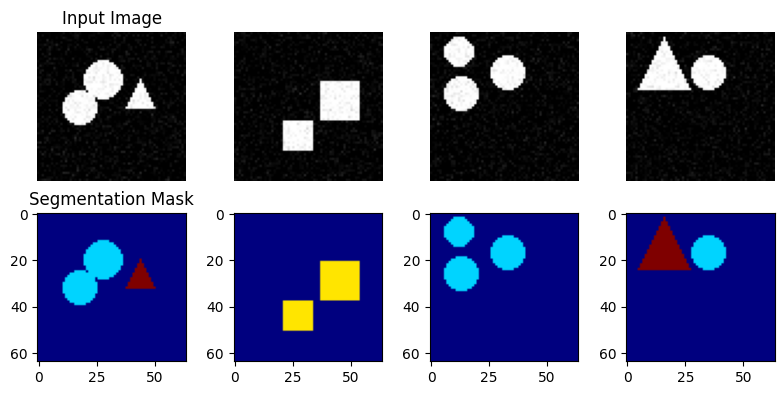

In [3]:
# Visualize some data
dataiter = iter(train_loader)
images, masks = next(dataiter)
def plot_samples(images, masks, n=4):
    plt.figure(figsize=(8,4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(images[i,0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Input Image")
        plt.subplot(2, n, n+i+1)
        plt.imshow(masks[i], cmap="jet", vmin=0, vmax=3)
        if i == 0:
            plt.title("Segmentation Mask")
    plt.tight_layout()
    plt.show()

plot_samples(images, masks)

Now let's define the U-Net model for multi-object segmentation:

In [4]:
# Define double convolution block for U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

# Define Down and Up blocks
class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        if diffY != 0 or diffX != 0:
            x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

# Define the Mini U-Net architecture
class MiniUNetMC(nn.Module):
    def __init__(self, in_ch=1, base=16, n_classes=4):
        super().__init__()
        self.inc   = DoubleConv(in_ch, base)        # 64
        self.down1 = Down(base, base*2)             # 32
        self.bot   = DoubleConv(base*2, base*4)     # 16
        self.up1   = Up(base*4 + base*2, base*2)    # 32
        self.up0   = Up(base*2 + base, base)        # 64
        self.outc  = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        xb = self.bot(x2)
        xu = self.up1(xb, x2)
        xu = self.up0(xu, x1)
        logits = self.outc(xu)
        return logits

# Instantiate the model and print number of parameters
model = MiniUNetMC(in_ch=1, base=16, n_classes=4).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))


Parameters (K): 118


Now it's time to train!

In [5]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Evaluation function
def evaluate_loss(loader):
    model.eval(); loss_sum = 0.0; n_items = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0)
            n_items += x.size(0)
    return loss_sum / max(1, n_items)

# Training loop
epochs = 10
train_losses, val_losses = [], []

for ep in range(1, epochs+1):
    model.train(); run_loss = 0.0; n = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * x.size(0)
        n += x.size(0)

    # Evaluate losses per epoch
    tr = run_loss / max(1, n)
    va = evaluate_loss(val_loader)
    train_losses.append(tr); val_losses.append(va)
    print(f"Epoch {ep:02d}/{epochs} | train loss {tr:.4f} | val loss {va:.4f}")


Epoch 01/10 | train loss 0.8145 | val loss 0.6746
Epoch 02/10 | train loss 0.4472 | val loss 0.3523
Epoch 03/10 | train loss 0.2619 | val loss 0.1955
Epoch 04/10 | train loss 0.1561 | val loss 0.1192
Epoch 05/10 | train loss 0.0999 | val loss 0.0805
Epoch 06/10 | train loss 0.0681 | val loss 0.0561
Epoch 07/10 | train loss 0.0493 | val loss 0.0425
Epoch 08/10 | train loss 0.0372 | val loss 0.0315
Epoch 09/10 | train loss 0.0287 | val loss 0.0271
Epoch 10/10 | train loss 0.0232 | val loss 0.0249


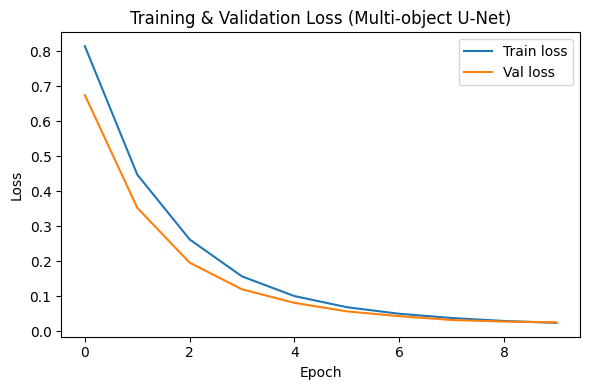

In [7]:
# Visualize training and validation loss
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training & Validation Loss (Multi-object U-Net)')
plt.legend(); plt.tight_layout(); plt.show()


Let's look at some results:

In [8]:
# Utility to convert mask to color image for visualization
CMAP = {0:(0,0,0), 1:(255,0,0), 2:(0,255,0), 3:(0,0,255)}
def mask_to_color(mask_np):
    h, w = mask_np.shape
    rgb = np.zeros((h,w,3), dtype=np.uint8)
    for k,(r,g,b) in CMAP.items():
        rgb[mask_np == k] = (r,g,b)
    return rgb


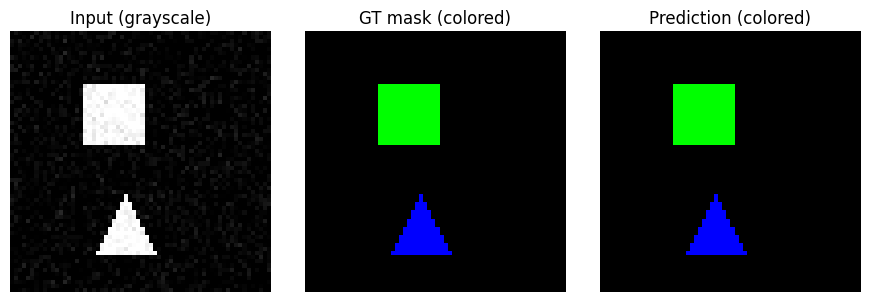

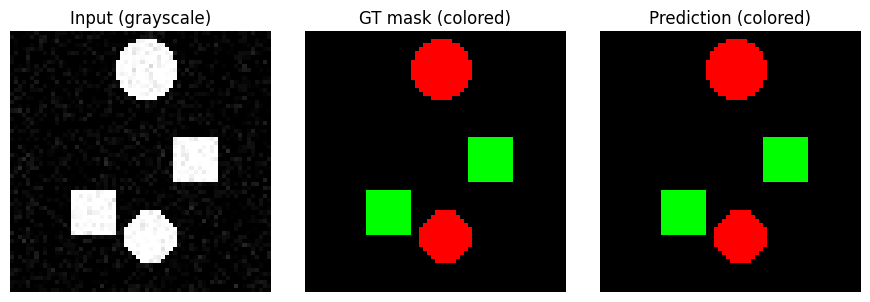

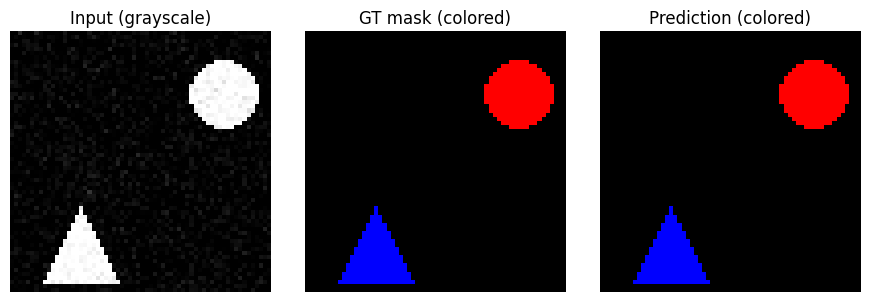

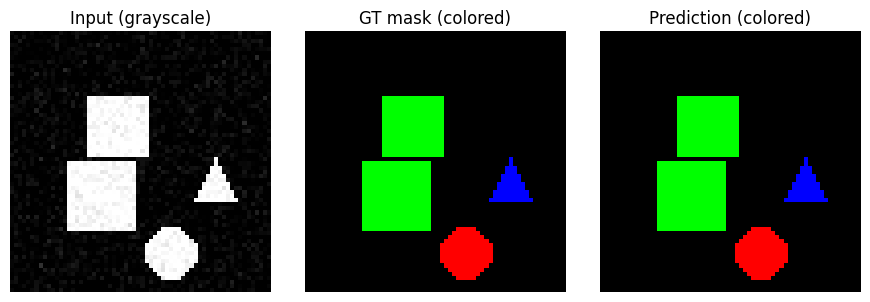

In [9]:
# Visualize some predictions
model.eval()
x_batch, y_batch = next(iter(val_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
with torch.no_grad():
    logits = model(x_batch)
    preds  = logits.argmax(dim=1)

n_show = 4
for i in range(n_show):
    x = x_batch[i,0].cpu().numpy()
    y = y_batch[i].cpu().numpy()
    p = preds[i].cpu().numpy()
    y_rgb = mask_to_color(y)
    p_rgb = mask_to_color(p)

    fig = plt.figure(figsize=(9,3))
    ax1 = fig.add_subplot(1,3,1); ax1.imshow(x, cmap='gray'); ax1.set_title('Input (grayscale)'); ax1.axis('off')
    ax2 = fig.add_subplot(1,3,2); ax2.imshow(y_rgb); ax2.set_title('GT mask (colored)'); ax2.axis('off')
    ax3 = fig.add_subplot(1,3,3); ax3.imshow(p_rgb); ax3.set_title('Prediction (colored)'); ax3.axis('off')
    plt.tight_layout(); plt.show()


Great, we have just trained our first U-Net for image segmentation! In the next notebook, let's see how U-Net performs on segmentation tasks using realistic real-world images.